# Mock Microbiome Community Generator

A general-purpose, reproducible tool for generating synthetic longitudinal
microbiome abundance data with one stable **Control** arm and any number of
**Treatment** arms, each exhibiting its own distinct compositional
dynamics.

## What this notebook is for

**1. Training and practice.** Real microbiome datasets are often
restricted, difficult to obtain, or too large and messy to use as a first
learning example. This generator produces a realistic-shaped dataset --
relative abundances that sum to 1.0 per sample, biological replicates,
repeated longitudinal sampling of the same subjects, and genuine
between-group compositional differences -- on demand, with no external
data dependency, so it can be used to practice or teach microbiome
statistics and visualization from a clean, known starting point.

**2. Benchmarking.** Because the dynamics are simulated according to a
known design (which taxa decline, which increase, and in which group),
the function also returns a **ground-truth reference table** alongside
the data. This makes it possible to run your own statistical test,
ordination method, or visualization pipeline on the generated data, then
directly check whether it correctly recovered the known, designed pattern
-- something that is impossible with real data, where the true underlying
biology is never fully known.

## How the generation algorithm works

The generator follows six explicit steps, each implemented as a clearly
commented block in the function below:

1. **Validate inputs** and label the taxa alphabetically (`A`, `B`, `C`, ...).
2. **Draw one random baseline composition per group** -- an independent,
   seeded random draw of relative abundances, normalized to sum to 1.0.
3. **Assign each Treatment group its own declining/increasing taxa.** A
   circular rotation walks a "window" of declining taxa around the taxon
   list, one step further for each successive Treatment group, so that
   different Treatment groups are guaranteed to differ from one another
   (the Control group's window is empty, so it has no systematic trend).
4. **Compute each group's expected (noise-free) composition at every
   week.** The Control arm stays at its baseline; each Treatment group's
   declining taxa shrink linearly toward a floor value, with the freed
   abundance redistributed proportionally across that group's increasing
   taxa, so the composition always still sums to 1.0.
5. **Generate individual replicate samples** by perturbing each week's
   expected composition with independent random noise, then
   renormalizing. The Control arm uses a smaller noise level by default,
   so it is both trend-free *and* visibly more stable than the Treatment
   arms -- matching how an untreated reference arm typically behaves in a
   real study.
6. **Assemble the results** into a tidy, long-format data table, plus a
   separate ground-truth table recording the designed dynamics for later
   validation use.

## Setup

Two imports and a fixed random seed are all this tool requires -- no
external statistics or plotting package is a hard dependency of the
generator itself (`matplotlib` is used later, only for the optional
demonstration plot).

In [1]:
import numpy as np
import pandas as pd

RANDOM_SEED = 42

## The generator function

Every step described in the preface above is marked with a `# ---- Step
N` comment in the code below, so the implementation can be read
side-by-side with the algorithm overview.

In [2]:
def generate_mock_microbiome_dataset(
    n_taxa=10,
    n_treatment_groups=1,
    n_replicates=8,
    n_weeks=8,
    min_abundance=0.03,
    max_abundance=0.40,
    control_noise=0.05,
    treatment_noise=0.35,
    decline_floor=0.15,
    n_declining_taxa=None,
    random_seed=RANDOM_SEED,
):
    """
    Generate a synthetic, longitudinal microbiome abundance dataset with
    one stable Control arm and any number of Treatment arms, each with
    its own distinct compositional dynamics.

    This is a general-purpose tool, not tied to a fixed two-group design:
    call it with `n_treatment_groups=1` for a simple two-arm experiment,
    or with `n_treatment_groups=3` (or more) to simulate a multi-arm
    trial in which every treatment arm responds differently. It is
    intended for two related uses: (1) generating training data to
    practice or teach microbiome visualization and statistics on, without
    needing access to a real (and often restricted or hard-to-obtain)
    dataset, and (2) generating benchmark data with a KNOWN ground truth
    (returned alongside the data) against which a statistical or
    visualization pipeline's ability to recover the true signal can be
    checked.

    ALGORITHM OVERVIEW
    -------------------
    1. Validate inputs and label the taxa (A, B, C, ...).
    2. Draw one random baseline relative-abundance profile per group,
       from independent (but seeded, reproducible) random draws.
    3. Assign each Treatment group its own, distinct set of "declining"
       and "increasing" taxa, using a circular rotation through the taxon
       list so that different treatment groups are guaranteed to differ
       from one another (the Control group is given an empty declining
       set, so its composition does not drift).
    4. For every week, compute each group's *expected* (noise-free)
       composition: Control stays at its baseline; each Treatment group's
       declining taxa are shrunk linearly toward `decline_floor` of their
       starting total, with the freed abundance redistributed
       proportionally across that group's increasing taxa.
    5. For every (group, week), generate `n_replicates` individual
       samples by perturbing the expected composition with random,
       independent replicate-level noise, then renormalizing so every
       sample's taxa still sum to 1.0. The Control arm uses a smaller
       noise level than the Treatment arms by default, so it is not only
       trend-free but also visibly more stable sample-to-sample --
       matching how a real untreated/reference arm typically behaves.
    6. Assemble every (group, week, replicate, taxon) observation into
       one tidy, long-format table, and separately record the ground
       truth (which taxa were designed to decline/increase in which
       group) for later validation use.

    Parameters
    ----------
    n_taxa : int
        Number of simulated bacterial taxa (labeled alphabetically, up
        to 26). Must be at least 4, so that at least 2 taxa can decline
        and at least 2 can increase in each Treatment group.
    n_treatment_groups : int
        Number of distinct Treatment arms to generate, in addition to
        the one Control arm. Must be at least 1. Each Treatment group is
        given its own distinct declining/increasing taxon assignment
        (see step 3 above); if `n_treatment_groups` is large relative to
        `n_taxa`, some groups' assignments will necessarily begin to
        repeat (a warning is printed in that case, since the rotation
        cannot manufacture more distinct patterns than the taxon list
        supports).
    n_replicates : int
        Number of subjects (biological replicates) sampled per group.
    n_weeks : int
        Number of longitudinal sampling occasions.
    min_abundance, max_abundance : float
        Range used to draw each group's baseline relative abundance per
        taxon, before normalization.
    control_noise : float
        Maximum fractional perturbation (+/-) applied to each taxon's
        abundance in an individual Control-arm replicate. Kept small by
        default so the Control arm shows minimal sample-to-sample change,
        consistent with it being an untreated reference arm.
    treatment_noise : float
        Maximum fractional perturbation (+/-) applied to each taxon's
        abundance in an individual Treatment-arm replicate. Can be set
        larger than `control_noise` to reflect a more variable biological
        response to treatment.
    decline_floor : float
        Fraction of its starting combined abundance that a Treatment
        group's declining taxa retain by the final week (e.g. 0.15 = a
        drop to 15% of the Week-1 total for that group's declining taxa).
    n_declining_taxa : int, optional
        Number of taxa that decline (with the remainder increasing) in
        each Treatment group. Defaults to `n_taxa // 2` (an even split).
    random_seed : int
        Seed for the random number generator, ensuring the entire
        dataset -- baselines, dynamics, and replicate noise -- is exactly
        reproducible.

    Returns
    -------
    df_long : pandas.DataFrame
        Tidy ("long-format") table, one row per taxon observation:

        Sample     : str   Unique sample id ("Group_Week_Replicate").
        SubjectID  : str   Subject id ("Group_Replicate"), constant
                            across weeks -- use to trace individual
                            trajectories.
        Group      : str   "Control", "Treatment_1", "Treatment_2", ...
        Week       : int   Longitudinal sampling occasion (1..n_weeks).
        Replicate  : int   Subject index within a group (1..n_replicates).
        Taxon      : str   Taxon label ("A", "B", ...).
        Abundance  : float Relative abundance (all taxa within one
                            Sample sum to 1.0).

        "Sample", "SubjectID", "Group", "Week", and "Replicate" are
        sample metadata; "Taxon" identifies the measured feature;
        "Abundance" is the sole measurement column.

    ground_truth : pandas.DataFrame
        One row per (Group, Taxon), recording the DESIGNED dynamics used
        to generate the data:

        Group      : str   Group name.
        Taxon      : str   Taxon label.
        Dynamics   : str   "stable", "declining", or "increasing".

        Intended for benchmarking: after running your own statistical or
        visualization pipeline on `df_long`, compare its conclusions
        against this table to check whether it correctly recovered the
        known, ground-truth pattern.
    """
    # ---- Step 1: validate inputs and label the taxa --------------------
    if n_taxa < 4:
        raise ValueError("n_taxa must be at least 4 (need >=2 declining and >=2 increasing taxa).")
    if n_taxa > 26:
        raise ValueError("n_taxa must be at most 26 (single-letter taxon labels A-Z).")
    if n_treatment_groups < 1:
        raise ValueError("n_treatment_groups must be at least 1.")
    if not (0 < decline_floor <= 1):
        raise ValueError("decline_floor must be in the interval (0, 1].")
    if not (0 <= control_noise < 1) or not (0 <= treatment_noise < 1):
        raise ValueError("control_noise and treatment_noise must be in [0, 1).")

    n_declining_taxa = n_declining_taxa or n_taxa // 2
    if not (1 <= n_declining_taxa <= n_taxa - 1):
        raise ValueError("n_declining_taxa must leave at least 1 taxon to increase.")

    taxa = [chr(ord("A") + i) for i in range(n_taxa)]
    rng_master = np.random.default_rng(random_seed)

    # ---- Step 2 & 3: build one configuration per group ------------------
    # Each group gets (a) its own random baseline composition, drawn from
    # an independent sub-seed, and (b) for Treatment groups, its own
    # declining/increasing taxon assignment.
    #
    # Distinct dynamics across Treatment groups are guaranteed by walking
    # a "window" of declining taxa around the (circular) taxon list, one
    # step further for each successive Treatment group -- so
    # Treatment_1's declining taxa start at position 0, Treatment_2's at
    # some offset further along the list, and so on, until either every
    # group has a unique window or the rotation has cycled back and
    # begun to repeat (only possible when n_treatment_groups is large
    # relative to n_taxa).
    group_names = ["Control"] + [f"Treatment_{i}" for i in range(1, n_treatment_groups + 1)]

    # Step size for the circular rotation: spreads the declining-taxa
    # windows as evenly as possible across the taxon list for the number
    # of treatment groups requested.
    rotation_step = max(1, n_taxa // n_treatment_groups)
    if n_treatment_groups > n_taxa:
        print(
            f"Warning: n_treatment_groups ({n_treatment_groups}) exceeds n_taxa "
            f"({n_taxa}); some treatment groups will necessarily share the same "
            "declining/increasing taxon assignment."
        )

    group_config = {}
    for g_index, group in enumerate(group_names):
        seed = int(rng_master.integers(0, 1_000_000))
        if group == "Control":
            declining, increasing = [], []  # no systematic trend at all
        else:
            treatment_index = g_index - 1  # 0-based index among Treatment groups only
            offset = (treatment_index * rotation_step) % n_taxa
            # Circular slice of length n_declining_taxa starting at `offset`
            declining = [taxa[(offset + k) % n_taxa] for k in range(n_declining_taxa)]
            increasing = [t for t in taxa if t not in declining]
        group_config[group] = {"seed": seed, "declining": declining, "increasing": increasing}

    # ---- Step 4: helper to compute a group's expected composition ------
    def _draw_baseline(seed):
        """Random starting relative-abundance profile for one group,
        drawn independently and normalized to sum to 1.0."""
        rng = np.random.default_rng(seed)
        base = rng.uniform(min_abundance, max_abundance, n_taxa)
        base = base / base.sum()
        base = np.clip(base, min_abundance, max_abundance)
        return base / base.sum()

    def _temporal_profile(base, week_index, declining, increasing):
        """Noise-free expected composition at a given week: the
        Control arm (empty `declining`) stays at baseline; a Treatment
        arm's declining taxa shrink linearly toward `decline_floor` of
        their starting total, and the freed abundance is redistributed
        proportionally across that arm's increasing taxa, so the profile
        still sums to 1.0."""
        if not declining:
            return base.copy()

        decline_frac = np.linspace(1.0, decline_floor, n_weeks)[week_index]
        profile = pd.Series(base, index=taxa).copy()

        declining_total = profile[declining].sum()
        increasing_total = profile[increasing].sum()

        profile[declining] = profile[declining] * decline_frac
        freed = declining_total * (1 - decline_frac)
        profile[increasing] = profile[increasing] + freed * (
            profile[increasing] / increasing_total
        )
        return (profile / profile.sum()).values

    # ---- Step 5: generate replicate-level samples for every group/week -
    records = []
    for group, cfg in group_config.items():
        base = _draw_baseline(cfg["seed"])
        rng = np.random.default_rng(cfg["seed"] + 1)
        # Control arm uses its own, smaller noise level by default, so it
        # is both trend-free (Step 4) and visibly more stable
        # replicate-to-replicate than the Treatment arms.
        noise_level = control_noise if group == "Control" else treatment_noise

        for week in range(1, n_weeks + 1):
            expected = _temporal_profile(base, week - 1, cfg["declining"], cfg["increasing"])

            for rep in range(1, n_replicates + 1):
                # Perturb the expected composition with independent
                # random noise, then renormalize so the sample's taxa
                # still sum to exactly 1.0.
                noise = rng.uniform(-noise_level, noise_level, n_taxa)
                observed = expected * (1 + noise)
                observed = np.clip(observed, min_abundance * 0.1, max_abundance)
                observed = observed / observed.sum()

                sample_id = f"{group}_{week}_{rep}"
                subject_id = f"{group}_{rep}"
                for taxon, value in zip(taxa, observed):
                    records.append(
                        {
                            "Sample": sample_id,
                            "SubjectID": subject_id,
                            "Group": group,
                            "Week": week,
                            "Replicate": rep,
                            "Taxon": taxon,
                            "Abundance": round(float(value), 5),
                        }
                    )

    df_long = pd.DataFrame.from_records(records)
    df_long["Group"] = pd.Categorical(df_long["Group"], categories=group_names, ordered=True)

    # ---- Step 6: assemble the ground-truth reference table -------------
    truth_records = []
    for group, cfg in group_config.items():
        for taxon in taxa:
            if taxon in cfg["declining"]:
                dynamics = "declining"
            elif taxon in cfg["increasing"]:
                dynamics = "increasing"
            else:
                dynamics = "stable"
            truth_records.append({"Group": group, "Taxon": taxon, "Dynamics": dynamics})
    ground_truth = pd.DataFrame.from_records(truth_records)

    return df_long, ground_truth

## Input validation

The function validates its inputs up front and raises a clear
`ValueError` for nonsensical configurations, rather than failing
obscurely partway through generation. The cell below deliberately
triggers each validation rule to confirm they behave as documented.

In [3]:
# Each of the following is expected to raise a ValueError with a clear message.
invalid_configs = [
    (dict(n_taxa=2), "n_taxa too small"),
    (dict(n_taxa=30), "n_taxa too large"),
    (dict(n_treatment_groups=0), "zero treatment groups"),
    (dict(decline_floor=1.5), "decline_floor out of range"),
    (dict(control_noise=1.2), "control_noise out of range"),
    (dict(n_declining_taxa=10), "n_declining_taxa leaves none to increase"),
]

for kwargs, description in invalid_configs:
    try:
        generate_mock_microbiome_dataset(**kwargs)
        print(f"{description}: NO ERROR RAISED (unexpected)")
    except ValueError as e:
        print(f"{description}: correctly raised -> {e}")

n_taxa too small: correctly raised -> n_taxa must be at least 4 (need >=2 declining and >=2 increasing taxa).
n_taxa too large: correctly raised -> n_taxa must be at most 26 (single-letter taxon labels A-Z).
zero treatment groups: correctly raised -> n_treatment_groups must be at least 1.
decline_floor out of range: correctly raised -> decline_floor must be in the interval (0, 1].
control_noise out of range: correctly raised -> control_noise and treatment_noise must be in [0, 1).
n_declining_taxa leaves none to increase: correctly raised -> n_declining_taxa must leave at least 1 taxon to increase.


## Demonstration 1: a simple two-arm experiment

Calling the function with its defaults (`n_treatment_groups=1`) reproduces
a straightforward Control-vs-Treatment design.

In [4]:
df_default, truth_default = generate_mock_microbiome_dataset()

print(f"Shape: {df_default.shape}")
print(f"Groups: {df_default['Group'].cat.categories.tolist()}")
print()
print("Ground truth (non-stable taxa only):")
truth_default[truth_default["Dynamics"] != "stable"]

Shape: (1280, 7)
Groups: ['Control', 'Treatment_1']

Ground truth (non-stable taxa only):


,Group,Taxon,Dynamics
10,Treatment_1,A,declining
11,Treatment_1,B,declining
12,Treatment_1,C,declining
13,Treatment_1,D,declining
14,Treatment_1,E,declining
15,Treatment_1,F,increasing
16,Treatment_1,G,increasing
17,Treatment_1,H,increasing
18,Treatment_1,I,increasing
19,Treatment_1,J,increasing


## Demonstration 2: multiple, distinct treatment groups

Setting `n_treatment_groups=3` simulates a multi-arm trial. Each
Treatment group's declining taxa are printed below, confirming they
differ from one another (per Step 3 of the algorithm) despite all being
generated by the same function call.

In [5]:
df_multi, truth_multi = generate_mock_microbiome_dataset(n_treatment_groups=3)

print(f"Shape: {df_multi.shape}")
print(f"Groups: {df_multi['Group'].cat.categories.tolist()}")
print()

for group in df_multi["Group"].cat.categories:
    if group == "Control":
        continue
    declining = truth_multi.loc[
        (truth_multi["Group"] == group) & (truth_multi["Dynamics"] == "declining"), "Taxon"
    ].tolist()
    increasing = truth_multi.loc[
        (truth_multi["Group"] == group) & (truth_multi["Dynamics"] == "increasing"), "Taxon"
    ].tolist()
    print(f"{group}: declining={declining}, increasing={increasing}")

Shape: (2560, 7)
Groups: ['Control', 'Treatment_1', 'Treatment_2', 'Treatment_3']

Treatment_1: declining=['A', 'B', 'C', 'D', 'E'], increasing=['F', 'G', 'H', 'I', 'J']
Treatment_2: declining=['D', 'E', 'F', 'G', 'H'], increasing=['A', 'B', 'C', 'I', 'J']
Treatment_3: declining=['A', 'G', 'H', 'I', 'J'], increasing=['B', 'C', 'D', 'E', 'F']


### Sanity check: does group membership really change a taxon's trajectory?

The plot below tracks a single taxon (Taxon A) across every group. If the
generator is working as designed, Taxon A's trajectory should differ
visibly by group -- flat in Control, and following each Treatment group's
own assigned dynamics elsewhere.

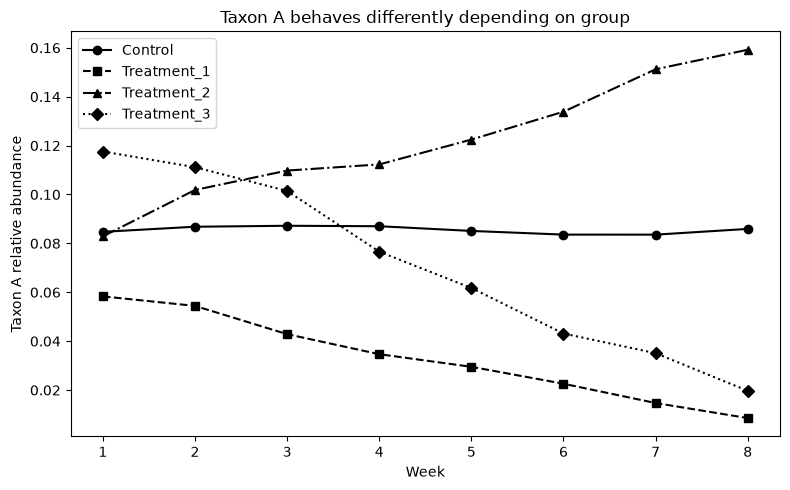

In [6]:
import matplotlib.pyplot as plt

mean_abundance = df_multi.groupby(["Group", "Week", "Taxon"])["Abundance"].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
markers = ["o", "s", "^", "D"]
linestyles = ["-", "--", "-.", ":"]

for i, group in enumerate(df_multi["Group"].cat.categories):
    trend = mean_abundance.loc[
        (mean_abundance["Group"] == group) & (mean_abundance["Taxon"] == "A")
    ].set_index("Week")["Abundance"]
    ax.plot(trend.index, trend.values, marker=markers[i % 4], linestyle=linestyles[i % 4],
            color="black", label=group)

ax.set_xlabel("Week")
ax.set_ylabel("Taxon A relative abundance")
ax.set_title("Taxon A behaves differently depending on group")
ax.legend()
fig.tight_layout()

**Reading the plot.** Control's line (circle markers, solid) stays flat
throughout, confirming minimal change as designed. Each Treatment group's
line follows its own distinct path -- some rising, some falling at
different rates -- confirming that `n_treatment_groups > 1` produces
genuinely different dynamics per group, not just noisy copies of the same
trend.

## Saving the generated data to CSV

Once a dataset looks right, it is often useful to save it to disk --
for sharing with a colleague, loading into another tool, or simply
avoiding having to regenerate it (and burn through random draws) every
time a notebook is restarted. Both the abundance table and its
ground-truth reference table are saved below; reading either back with
`pd.read_csv` recovers an identical table (aside from `Group`'s dtype,
which round-trips as a plain string rather than the ordered `Categorical`
used in memory -- reapply `pd.Categorical(..., ordered=True)` after
reloading if that ordering matters downstream).

In [7]:
# Save the multi-group demonstration dataset generated above.
# Both files are written to the current working directory; adjust the
# path if you would rather save elsewhere (e.g. "data/community.csv").
data_csv_path = "mock_community_data.csv"
truth_csv_path = "mock_community_ground_truth.csv"

df_multi.to_csv(data_csv_path, index=False)
truth_multi.to_csv(truth_csv_path, index=False)

print(f"Saved {len(df_multi):,} rows to '{data_csv_path}'")
print(f"Saved {len(truth_multi):,} rows to '{truth_csv_path}'")

# Quick round-trip check: read the abundance table back and confirm it
# matches what was written.
reloaded = pd.read_csv(data_csv_path)
assert reloaded.shape == df_multi.shape
assert np.allclose(reloaded["Abundance"], df_multi["Abundance"].values)
print("Round-trip check passed: reloaded CSV matches the original DataFrame.")

Saved 2,560 rows to 'mock_community_data.csv'
Saved 40 rows to 'mock_community_ground_truth.csv'
Round-trip check passed: reloaded CSV matches the original DataFrame.


## Using the ground truth for benchmarking

The `ground_truth` table returned alongside the data is the key feature
that supports the "benchmarking" use case described in the preface. As a
minimal example, the cell below runs a simple mean-based up/down
classifier (Week 8 vs. Week 1) for each taxon in each Treatment group, and
checks its predictions against the known ground truth.

In [8]:
def simple_classifier(df, group, threshold=0.05):
    '''Toy up/down/stable classifier: compares each taxon's mean
    abundance at the first vs. last week within one group, purely as a
    minimal illustration of how to validate a pipeline against the
    ground-truth table -- not a serious statistical method on its own.'''
    subset = df[df["Group"] == group]
    first_week, last_week = subset["Week"].min(), subset["Week"].max()

    predictions = []
    for taxon, taxon_df in subset.groupby("Taxon"):
        mean_first = taxon_df.loc[taxon_df["Week"] == first_week, "Abundance"].mean()
        mean_last = taxon_df.loc[taxon_df["Week"] == last_week, "Abundance"].mean()
        relative_change = (mean_last - mean_first) / mean_first

        if relative_change < -threshold:
            prediction = "declining"
        elif relative_change > threshold:
            prediction = "increasing"
        else:
            prediction = "stable"
        predictions.append({"Group": group, "Taxon": taxon, "Predicted": prediction})

    return pd.DataFrame(predictions)


# Run the toy classifier on every Treatment group and compare to ground truth
all_predictions = pd.concat(
    [simple_classifier(df_multi, g) for g in df_multi["Group"].cat.categories if g != "Control"],
    ignore_index=True,
)

comparison = all_predictions.merge(truth_multi, on=["Group", "Taxon"])
comparison["Correct"] = comparison["Predicted"] == comparison["Dynamics"]

print(f"Classifier accuracy: {comparison['Correct'].mean():.1%}")
comparison

Classifier accuracy: 100.0%


,Group,Taxon,Predicted,Dynamics,Correct
0,Treatment_1,A,declining,declining,True
1,Treatment_1,B,declining,declining,True
2,Treatment_1,C,declining,declining,True
3,Treatment_1,D,declining,declining,True
4,Treatment_1,E,declining,declining,True
5,Treatment_1,F,increasing,increasing,True
6,Treatment_1,G,increasing,increasing,True
7,Treatment_1,H,increasing,increasing,True
8,Treatment_1,I,increasing,increasing,True
9,Treatment_1,J,increasing,increasing,True


**Interpretation.** This is deliberately a minimal, illustrative
classifier -- comparing only two weeks' means -- not a method worth using
in practice (the notebook `microbiome_visualization_tutorial.ipynb`
demonstrates a proper Mann-Whitney U + Benjamini-Hochberg approach
instead). What matters here is the *workflow*: generate data with a known
design, run any pipeline you want to evaluate, and score its predictions
directly against `ground_truth` -- the pattern this tool is built to
support.

## Visualizing community separation with PCoA

The classifier check above confirms the generator's dynamics are
recoverable numerically; a Principal Coordinates Analysis (PCoA)
ordination makes the same separation visible directly. The functions
below (from the companion `pcoa_visualization.py` module) are embedded
here in full so this notebook remains self-contained -- compute a
Bray-Curtis distance matrix between samples, run classical PCoA, and plot
the result -- and are written to handle an arbitrary number of groups
(one Control arm plus any number of Treatment arms), not just a fixed
pair, consistent with `n_treatment_groups` above.

As throughout this project, groups are distinguished by marker shape,
fill, and line style rather than color, so the figure remains legible in
grayscale.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform


# ---------------------------------------------------------------------------
# A fixed palette of (marker, linestyle) combinations, cycled through in
# order as groups are encountered. Eight combinations are provided --
# enough for a Control arm plus up to seven Treatment arms before any
# repetition is needed. Fill alternates open (white) / filled (black) each
# time the marker shape itself repeats, adding a further distinguishing
# cue if more than eight groups are ever plotted.
# ---------------------------------------------------------------------------
_MARKERS = ["o", "^", "s", "D", "v", "P", "X", "*"]
_LINESTYLES = ["-", "--", "-.", ":", "-", "--", "-.", ":"]


def get_group_styles(groups):
    """
    Build a black-and-white marker/linestyle/fill style dictionary for an
    arbitrary list of group names, so that every group in a plot remains
    visually distinguishable without relying on color.

    Parameters
    ----------
    groups : list of str
        Group names, in the order they should be styled (the first group
        is conventionally the Control/reference arm, but this function
        does not require that).

    Returns
    -------
    dict
        Maps each group name to a style dict with keys "marker",
        "linestyle", and "facecolor" ("white" or "black").
    """
    n_available = len(_MARKERS)
    if len(groups) > n_available:
        print(
            f"Warning: {len(groups)} groups requested but only {n_available} "
            "distinct marker/linestyle combinations are defined; styles will "
            "repeat and may be harder to visually distinguish. Consider "
            "plotting a subset of groups at a time instead."
        )

    styles = {}
    for i, group in enumerate(groups):
        cycle_count = i // n_available  # how many times we've wrapped around
        styles[group] = {
            "marker": _MARKERS[i % n_available],
            "linestyle": _LINESTYLES[i % n_available],
            "facecolor": "white" if cycle_count % 2 == 0 else "black",
        }
    return styles


def compute_bray_curtis_distance_matrix(df, sample_col="Sample", taxon_col="Taxon", value_col="Abundance"):
    """
    Compute a pairwise Bray-Curtis dissimilarity matrix between samples
    from a long-format abundance table.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table.
    sample_col, taxon_col, value_col : str
        Column names identifying samples, taxa, and abundance values.

    Returns
    -------
    pandas.DataFrame
        A square, symmetric sample x sample distance matrix.
    """
    wide = df.pivot(index=sample_col, columns=taxon_col, values=value_col)
    dist = squareform(pdist(wide.values, metric="braycurtis"))
    return pd.DataFrame(dist, index=wide.index, columns=wide.index)


def perform_pcoa(distance_df, n_axes=2):
    """
    Perform classical (Torgerson) Principal Coordinates Analysis via
    eigendecomposition of the double-centered squared-distance matrix.

    Parameters
    ----------
    distance_df : pandas.DataFrame
        Square, symmetric distance matrix.
    n_axes : int
        Number of ordination axes to return.

    Returns
    -------
    coords_df : pandas.DataFrame
        Sample coordinates on axes "PC1", "PC2", ..., indexed by sample.
    pct_explained : numpy.ndarray
        Percentage of total variance explained by each returned axis.
    """
    D = distance_df.values
    n = D.shape[0]
    J = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 * J @ (D ** 2) @ J

    eigvals, eigvecs = np.linalg.eigh(B)
    order = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    positive = eigvals > 1e-10
    coords = eigvecs[:, positive] * np.sqrt(eigvals[positive])
    pct_explained = eigvals[positive] / eigvals[positive].sum() * 100

    n_axes = min(n_axes, coords.shape[1])
    col_names = [f"PC{i + 1}" for i in range(n_axes)]
    coords_df = pd.DataFrame(coords[:, :n_axes], index=distance_df.index, columns=col_names)
    return coords_df, pct_explained[:n_axes]


def plot_pcoa(
    coords_df,
    metadata,
    group_col="Group",
    time_col=None,
    pct_explained=None,
    ax=None,
    figsize=(9, 8),
    draw_ellipses=True,
    show_individual_points=True,
    title=None,
):
    """
    Plot a black-and-white PCoA ordination for an arbitrary number of
    groups, either as a single static snapshot or, if `time_col` is
    given, as a longitudinal ordination with one centroid + confidence
    ellipse per (group, time point), each labeled with its time-point
    value, and a dotted trajectory line connecting each group's centroids
    in chronological order.

    Groups are distinguished purely by marker shape, fill, and (for
    ellipses/trajectories) line style -- see `get_group_styles` -- so the
    figure remains legible without color and scales to any number of
    Treatment arms, not just a single Control-vs-Treatment pair.

    Parameters
    ----------
    coords_df : pandas.DataFrame
        PCoA coordinates ("PC1", "PC2", ...), indexed by sample, as
        returned by `perform_pcoa`.
    metadata : pandas.DataFrame
        Sample metadata (same index as `coords_df`), containing at least
        `group_col` (and `time_col`, if longitudinal plotting is used).
    group_col : str
        Metadata column identifying each sample's group.
    time_col : str, optional
        Metadata column identifying each sample's time point. If
        provided, a longitudinal ordination (per-time centroids +
        trajectory) is drawn; if omitted, a static ordination (one
        centroid per group) is drawn instead.
    pct_explained : array-like, optional
        Percentage variance explained per axis, used to label the axes.
    ax : matplotlib.axes.Axes, optional
    figsize : tuple
    draw_ellipses : bool
        Whether to draw a +/-2 SD confidence ellipse around each
        group (static mode) or group/time-point (longitudinal mode)
        centroid.
    show_individual_points : bool
        Whether to overlay individual sample points beneath the
        centroids.
    title : str, optional

    Returns
    -------
    matplotlib.axes.Axes
    """
    join_cols = [group_col] + ([time_col] if time_col else [])
    plot_df = coords_df.join(metadata[join_cols])
    groups = plot_df[group_col].astype(str).unique().tolist()
    # Keep Control (if present) first, then sort the rest for a stable,
    # predictable legend/plotting order regardless of input row order.
    groups = sorted(groups, key=lambda g: (g != "Control", g))
    styles = get_group_styles(groups)

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    for group in groups:
        style = styles[group]
        fill = "black" if style["facecolor"] == "black" else "white"
        grp_all = plot_df[plot_df[group_col].astype(str) == group]

        if time_col is None:
            # ---- Static mode: one centroid (+ ellipse) per group ----
            if show_individual_points:
                ax.scatter(grp_all["PC1"], grp_all["PC2"], marker=style["marker"],
                           facecolors=fill, edgecolors="black", linewidths=0.7,
                           s=55, alpha=0.85, zorder=2)

            cx, cy = grp_all["PC1"].mean(), grp_all["PC2"].mean()
            ax.scatter(cx, cy, marker=style["marker"], facecolors=fill,
                       edgecolors="black", linewidths=1.8, s=220, label=group, zorder=3)

            if draw_ellipses and len(grp_all) > 1:
                width = 2 * grp_all["PC1"].std()
                height = 2 * grp_all["PC2"].std()
                ax.add_patch(mpatches.Ellipse((cx, cy), width, height, fill=False,
                                               edgecolor="black", linestyle=style["linestyle"],
                                               linewidth=1.3, alpha=0.8, zorder=1))
        else:
            # ---- Longitudinal mode: centroid + ellipse per (group, time),
            # connected by a trajectory line in chronological order ----
            if show_individual_points:
                ax.scatter(grp_all["PC1"], grp_all["PC2"], marker=style["marker"],
                           facecolors=fill, edgecolors="black", linewidths=0.4,
                           s=20, alpha=0.4, zorder=1)

            centroids = grp_all.groupby(time_col)[["PC1", "PC2"]].agg(["mean", "std"])
            centroids.columns = ["PC1_mean", "PC1_std", "PC2_mean", "PC2_std"]
            centroids = centroids.sort_index()

            ax.plot(centroids["PC1_mean"], centroids["PC2_mean"],
                    linestyle=style["linestyle"], color="black", linewidth=1.4, zorder=2)

            ax.scatter(centroids["PC1_mean"], centroids["PC2_mean"], marker=style["marker"],
                       facecolors=fill, edgecolors="black", linewidth=1.3, s=120,
                       label=group, zorder=4)

            if draw_ellipses:
                for t, row in centroids.iterrows():
                    ax.add_patch(mpatches.Ellipse(
                        (row["PC1_mean"], row["PC2_mean"]),
                        width=2 * row["PC1_std"], height=2 * row["PC2_std"],
                        fill=False, edgecolor="black", linestyle=style["linestyle"],
                        alpha=0.55, linewidth=0.8, zorder=2,
                    ))

            # Label each centroid with its time-point value, so the
            # chronological order along the trajectory is explicit rather
            # than only implied by the dotted/dashed line direction.
            for t, row in centroids.iterrows():
                ax.annotate(str(t), (row["PC1_mean"], row["PC2_mean"]),
                            textcoords="offset points", xytext=(6, 6),
                            fontsize=8, fontweight="bold", zorder=5)

    xlabel, ylabel = "PC1", "PC2"
    if pct_explained is not None:
        xlabel += f" ({pct_explained[0]:.1f}% variance explained)"
        ylabel += f" ({pct_explained[1]:.1f}% variance explained)"
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title=group_col, loc="best")
    if title:
        ax.set_title(title, fontweight="bold")
    return ax


def visualize_pcoa(
    df,
    group_col="Group",
    time_col=None,
    sample_col="Sample",
    taxon_col="Taxon",
    value_col="Abundance",
    ax=None,
    figsize=(9, 8),
    draw_ellipses=True,
    show_individual_points=True,
    title=None,
):
    """
    All-in-one convenience wrapper: compute the Bray-Curtis distance
    matrix, run PCoA, and plot the ordination, directly from a
    long-format abundance table -- e.g. the `df_long` output of
    `generate_mock_microbiome_dataset`.

    Equivalent to calling `compute_bray_curtis_distance_matrix`,
    `perform_pcoa`, and `plot_pcoa` in sequence; use those functions
    individually instead if you need the intermediate distance matrix or
    coordinates for further analysis.

    Parameters
    ----------
    df : pandas.DataFrame
        Long-format abundance table with sample metadata columns
        (including `group_col`, and `time_col` if longitudinal plotting
        is requested) plus `sample_col`, `taxon_col`, `value_col`.
    group_col, time_col, sample_col, taxon_col, value_col : str
        Column names, as in `plot_pcoa` and `compute_bray_curtis_distance_matrix`.
    ax, figsize, draw_ellipses, show_individual_points, title :
        Passed through to `plot_pcoa`.

    Returns
    -------
    matplotlib.axes.Axes
    """
    distance_matrix = compute_bray_curtis_distance_matrix(
        df, sample_col=sample_col, taxon_col=taxon_col, value_col=value_col
    )
    coords, pct_explained = perform_pcoa(distance_matrix)

    meta_cols = [group_col] + ([time_col] if time_col else [])
    metadata = df.drop_duplicates(sample_col).set_index(sample_col)[meta_cols]

    return plot_pcoa(
        coords, metadata, group_col=group_col, time_col=time_col,
        pct_explained=pct_explained, ax=ax, figsize=figsize,
        draw_ellipses=draw_ellipses, show_individual_points=show_individual_points,
        title=title,
    )

### Static ordination: does community composition differ by group?

Using the Week-8 snapshot of the multi-group dataset generated above,
each group's samples should cluster separately if the generator's
between-group differences are real and detectable -- exactly what a PCoA
plot is designed to show at a glance.

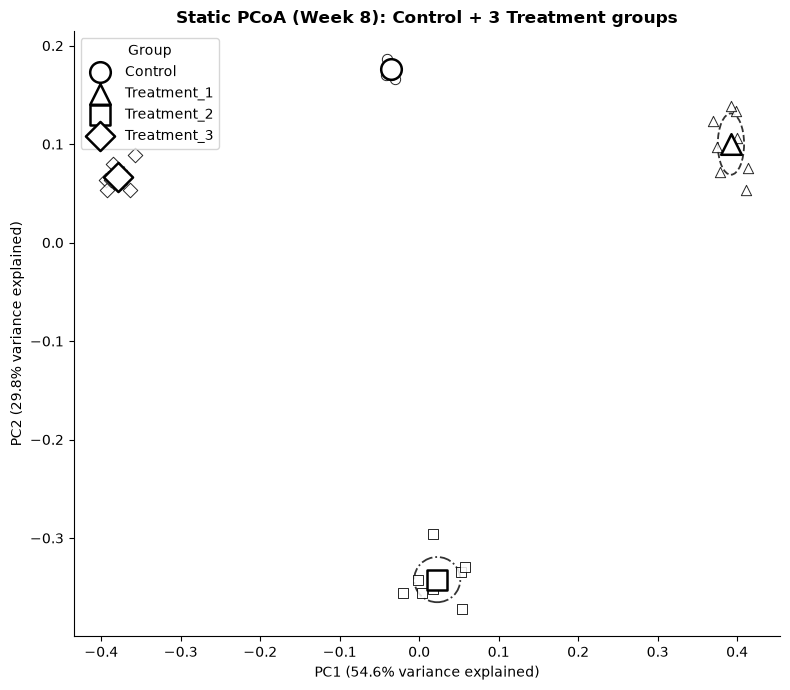

In [10]:
snapshot_multi = df_multi[df_multi["Week"] == df_multi["Week"].max()]

fig, ax = plt.subplots(figsize=(8, 7))
visualize_pcoa(snapshot_multi, ax=ax,
               title=f"Static PCoA (Week {df_multi['Week'].max()}): "
                     f"Control + {df_multi['Group'].nunique() - 1} Treatment groups")
fig.tight_layout()

### Longitudinal ordination: how does each group's trajectory diverge over time?

Passing `time_col="Week"` switches `visualize_pcoa` into its longitudinal
mode: one centroid and confidence ellipse per (group, week), connected by
a trajectory line in chronological order. The Control arm should stay
clustered in one small region throughout, while each Treatment arm traces
its own distinct path -- a direct visual counterpart to the ground-truth
table above.

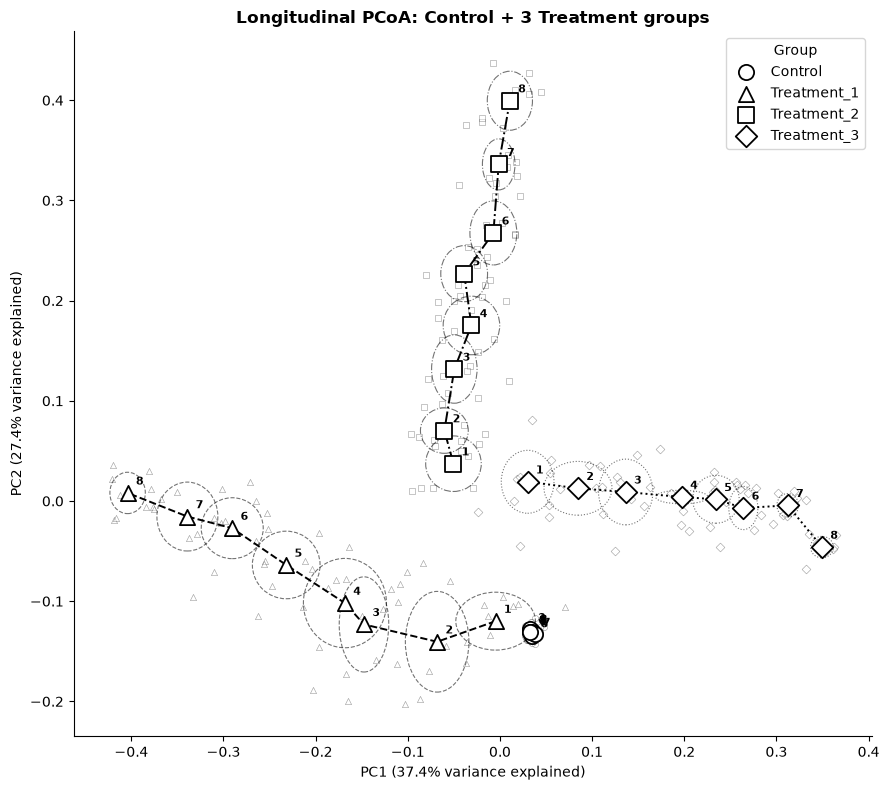

In [11]:
fig, ax = plt.subplots(figsize=(9, 8))
visualize_pcoa(df_multi, time_col="Week", ax=ax,
               title="Longitudinal PCoA: Control + 3 Treatment groups")
fig.tight_layout()

**Interpretation.** If the generator is working as intended, this figure
should show four visually separated clusters/trajectories -- Control
stationary, and each Treatment group moving along its own path, distinct
from the others in both direction and shape. This is the same check
performed numerically by the toy classifier above, now made visible: a
mismatch here (e.g. two Treatment groups' trajectories overlapping almost
completely) would be a useful early warning that the generator's
parameters need adjusting -- for instance, `n_treatment_groups` set too
high relative to `n_taxa`, causing declining-taxon sets to overlap too
much between groups (see the warning printed by the generator itself in
that case).